# Note de transmission - Jeu de données Détection de Fraude

## 1. Périmètre et Données
* Dataset initial : 493 604 lignes et 12 colonnes
* Nettoyage effectué : Suppression de `zone_differente_habituelle` et `nb_transactions_derniere_heure` malgré qu'elles sont théoriquement essentielle à la detection de fraude. Cepenldant dans le dataset fourni elles presentent une variance nulle ( 100 pourcent des valeurs à 0). elles ne peuvent donc pas alimenter le modèle.
* Dans la variable canal remplacement des valeurs manquantes par inconnu vu la quantité et l'utilité de la modalité pour le ML

## 2. Insights Métier & EDA
* Cible (`fraude`) : Fort déséquilibre de classe (à prendre en compte pour le rééquilibrage / choix des métriques).
Avec 481235 transactions legitimes sur 493604 pour un taux de 97.494145. 
nombre_de_fraudes  total_transactions  taux_de_fraude_pct
canal                                                             
app                   6755              270251            2.499528
USSD                  3690              147360            2.504072
agent                 1876               73894            2.538772
Inconnu                 48                2099            2.286803

* Facteurs discriminants : Analyse des taux de fraude par `type` de transaction
  nombre_de_fraudes  total_transactions  taux_de_fraude_pct
type                                                                
transfert               6267              247324            2.533923
paiement                3666              147803            2.480329
retrait                 1836               74061            2.479038
dépôt                    600               24416            2.457405 
Analyse des taux de fraude par`canal` effectuée.
nombre_de_fraudes  total_transactions  taux_de_fraude_pct
canal                                                             
app                   6755              270251            2.499528
USSD                  3690              147360            2.504072
agent                 1876               73894            2.538772
Inconnu                 48                2099            2.286803
* Corrélation : Forte colinéarité notée entre `montant` et `ecart_montant_moyen` (r = 0.89).

## 3. Recommandations pour le Machine Learning
* Encodage conseillé : One-Hot Encoding (`get_dummies`) pour `type` et `canal`.
* Normalisation : Utiliser idéalement un `RobustScaler` sur les variables de montant/heure post-split.

In [33]:
#Importation du fichier
import pandas as pd
df=pd.read_csv("../data/processed/dataset_fraude.csv")
df.head()

,id_transaction,montant,type,canal,heure,ecart_montant_moyen,ecart_heure_habituelle,nb_transactions_derniere_heure,zone_differente_habituelle,nouvel_appareil,nouveau_destinataire,fraude
0,txn_00405079,9249.0,transfert,app,10,1.008213,4.246094,0.0,0,False,False,False
1,txn_00404809,11504.0,transfert,app,14,1.243810,4.000000,0.0,0,False,False,False
2,txn_00334072,950.0,transfert,app,18,0.091553,6.000000,0.0,0,False,False,False
3,txn_00020793,6938.0,paiement,app,14,0.959038,0.000000,0.0,0,False,False,False
4,txn_00333619,2718.0,paiement,app,17,0.379596,3.000000,0.0,0,False,True,False


In [34]:
#Nombre de lignes et de colonnes 
df.shape

(493604, 12)

In [35]:
#Valeurs manquantes
df.isnull().sum()

id_transaction                       0
montant                              0
type                                 0
canal                             2099
heure                                0
ecart_montant_moyen                  0
ecart_heure_habituelle               0
nb_transactions_derniere_heure       0
zone_differente_habituelle           0
nouvel_appareil                      0
nouveau_destinataire                 0
fraude                               0
dtype: int64

In [36]:
# Liste des catégories uniques
print(df["canal"].unique())

<StringArray>
['app', 'USSD', 'agent', nan]
Length: 4, dtype: str


In [37]:
#les 20 premieres lignes de la variables canal
df[df["canal"].isna()].head(20)

,id_transaction,montant,type,canal,heure,ecart_montant_moyen,ecart_heure_habituelle,nb_transactions_derniere_heure,zone_differente_habituelle,nouvel_appareil,nouveau_destinataire,fraude
42,txn_00444085,5648.0,transfert,NaN,13,0.978501,2.404762,0.0,0,False,False,False
150,txn_00427373,13336.0,paiement,NaN,9,2.370486,5.085106,0.0,0,False,False,False
319,txn_00028806,18837.0,transfert,NaN,13,2.339139,1.056604,0.0,0,False,True,False
370,txn_00223363,4811.0,paiement,NaN,14,0.734579,1.222222,0.0,0,False,False,False
726,txn_00413125,2052.0,retrait,NaN,15,0.148629,1.150000,0.0,0,False,False,False
1155,txn_00377111,3788.0,transfert,NaN,16,0.399145,1.795699,0.0,0,False,False,False
1176,txn_00311320,6306.0,transfert,NaN,17,0.608673,0.350000,0.0,0,False,False,False
1709,txn_00441148,9285.0,transfert,NaN,22,0.555738,9.257143,0.0,0,False,False,False
1880,txn_00156005,2056.0,retrait,NaN,19,0.291704,3.678571,1.0,0,False,False,False
2136,txn_00125208,958.0,paiement,NaN,13,0.067468,0.527473,0.0,0,False,False,False


In [38]:
# Taux de fraude sur les valeurs manquantes
df[df["canal"].isna()]["fraude"].value_counts(normalize=True) * 100

fraude
False    97.713197
True      2.286803
Name: proportion, dtype: float64

In [39]:
#Remplacement des valeurs manquantes de la variable canal par Inconnu
df["canal"] = df["canal"].fillna("Inconnu")

In [40]:
# Liste des catégories uniques
print(df["canal"].unique())

<StringArray>
['app', 'USSD', 'agent', 'Inconnu']
Length: 4, dtype: str


In [41]:
#Valeurs manquantes
df.isnull().sum()

id_transaction                    0
montant                           0
type                              0
canal                             0
heure                             0
ecart_montant_moyen               0
ecart_heure_habituelle            0
nb_transactions_derniere_heure    0
zone_differente_habituelle        0
nouvel_appareil                   0
nouveau_destinataire              0
fraude                            0
dtype: int64

In [42]:
# Compter le nombre de lignes doublons
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons stricts : {nb_doublons}")

Nombre de doublons stricts : 0


In [43]:
#Verification des types de variables 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 493604 entries, 0 to 493603
Data columns (total 12 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id_transaction                  493604 non-null  str    
 1   montant                         493604 non-null  float64
 2   type                            493604 non-null  str    
 3   canal                           493604 non-null  str    
 4   heure                           493604 non-null  int64  
 5   ecart_montant_moyen             493604 non-null  float64
 6   ecart_heure_habituelle          493604 non-null  float64
 7   nb_transactions_derniere_heure  493604 non-null  float64
 8   zone_differente_habituelle      493604 non-null  int64  
 9   nouvel_appareil                 493604 non-null  bool   
 10  nouveau_destinataire            493604 non-null  bool   
 11  fraude                          493604 non-null  bool   
dtypes: bool(3), float64(4), int

In [44]:
#Verification des valeurs aberrantes
df.describe()

,montant,heure,ecart_montant_moyen,ecart_heure_habituelle,nb_transactions_derniere_heure,zone_differente_habituelle
count,4.936040e+05,493604.000000,493604.000000,493604.000000,493604.000000,493604.0
mean,9.173661e+03,14.246094,1.281059,3.796713,0.007016,0.0
std,3.251402e+04,4.643624,5.005455,2.893817,0.083902,0.0
min,1.000000e+02,0.000000,0.001786,0.000000,0.000000,0.0
25%,2.234000e+03,11.000000,0.262842,1.500000,0.000000,0.0
50%,4.143000e+03,14.000000,0.526602,3.188679,0.000000,0.0
75%,7.796000e+03,17.000000,1.062398,5.478261,0.000000,0.0
max,2.000000e+06,23.000000,535.871612,22.000000,2.000000,0.0


In [45]:
df.describe(include="all")

,id_transaction,montant,type,canal,heure,ecart_montant_moyen,ecart_heure_habituelle,nb_transactions_derniere_heure,zone_differente_habituelle,nouvel_appareil,nouveau_destinataire,fraude
count,493604,4.936040e+05,493604,493604,493604.000000,493604.000000,493604.000000,493604.000000,493604.0,493604,493604,493604
unique,493604,NaN,4,4,NaN,NaN,NaN,NaN,NaN,2,2,2
top,txn_00405079,NaN,transfert,app,NaN,NaN,NaN,NaN,NaN,False,False,False
freq,1,NaN,247324,270251,NaN,NaN,NaN,NaN,NaN,492775,411208,481235
mean,NaN,9.173661e+03,NaN,NaN,14.246094,1.281059,3.796713,0.007016,0.0,NaN,NaN,NaN
std,NaN,3.251402e+04,NaN,NaN,4.643624,5.005455,2.893817,0.083902,0.0,NaN,NaN,NaN
min,NaN,1.000000e+02,NaN,NaN,0.000000,0.001786,0.000000,0.000000,0.0,NaN,NaN,NaN
25%,NaN,2.234000e+03,NaN,NaN,11.000000,0.262842,1.500000,0.000000,0.0,NaN,NaN,NaN
50%,NaN,4.143000e+03,NaN,NaN,14.000000,0.526602,3.188679,0.000000,0.0,NaN,NaN,NaN
75%,NaN,7.796000e+03,NaN,NaN,17.000000,1.062398,5.478261,0.000000,0.0,NaN,NaN,NaN


In [46]:
#Verification de l'equilibre de la variable fraude
df["fraude"].value_counts(normalize=True) * 100

fraude
False    97.494145
True      2.505855
Name: proportion, dtype: float64

<Axes: ylabel='Frequency'>

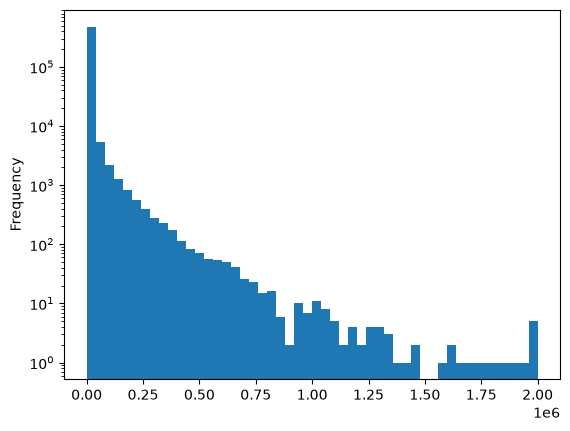

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
# Histogramme pour la variable 'montant'
df['montant'].plot(kind='hist', bins=50, log=True)

<Axes: >

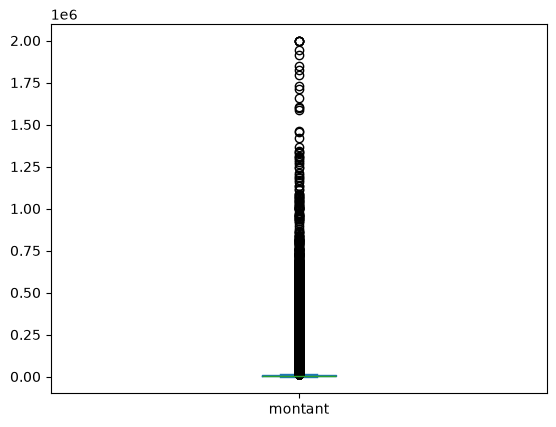

In [48]:
df['montant'].plot(kind='box')

<Axes: >

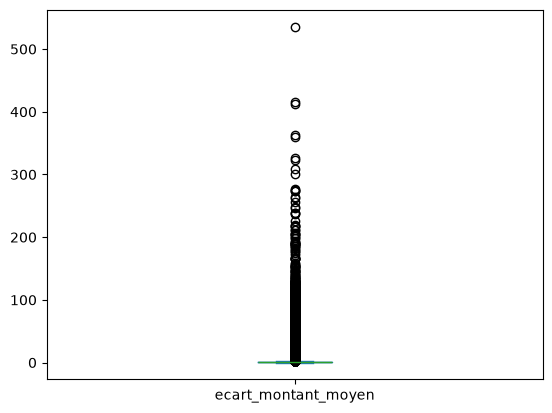

In [49]:
df['ecart_montant_moyen'].plot(kind='box')

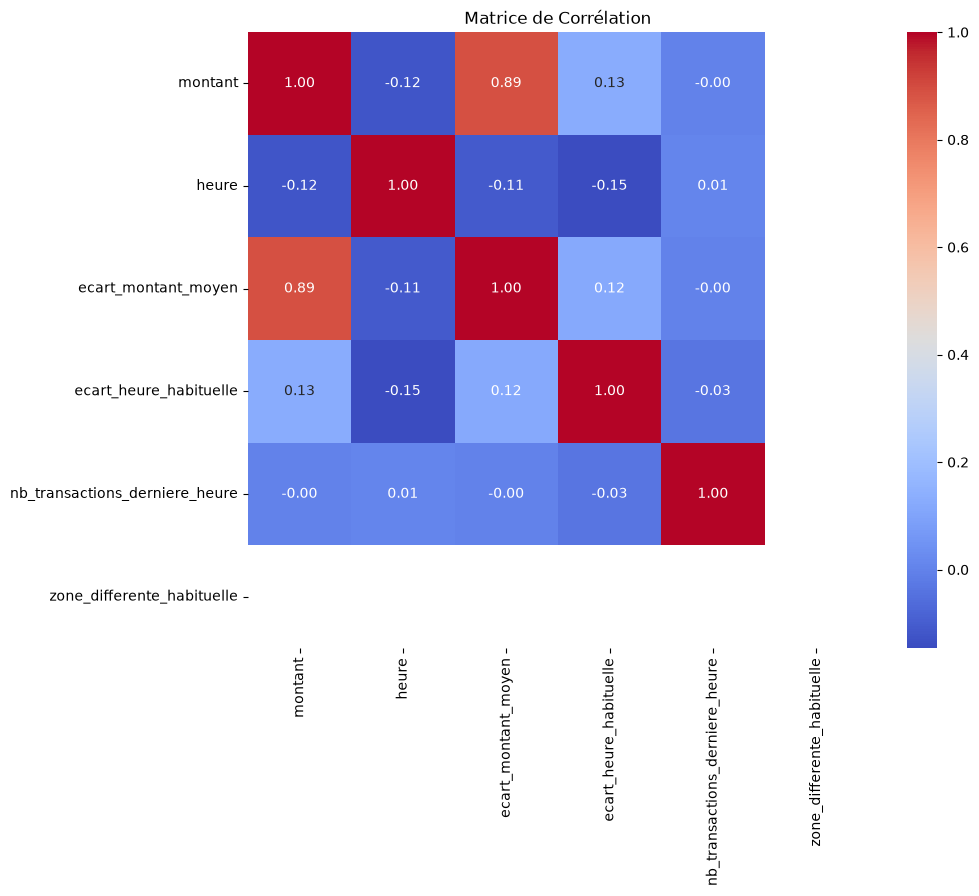

In [50]:
plt.figure(figsize=(10, 8))
# Sélection uniquement des colonnes numériques
df_numeric = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de Corrélation")
plt.show()

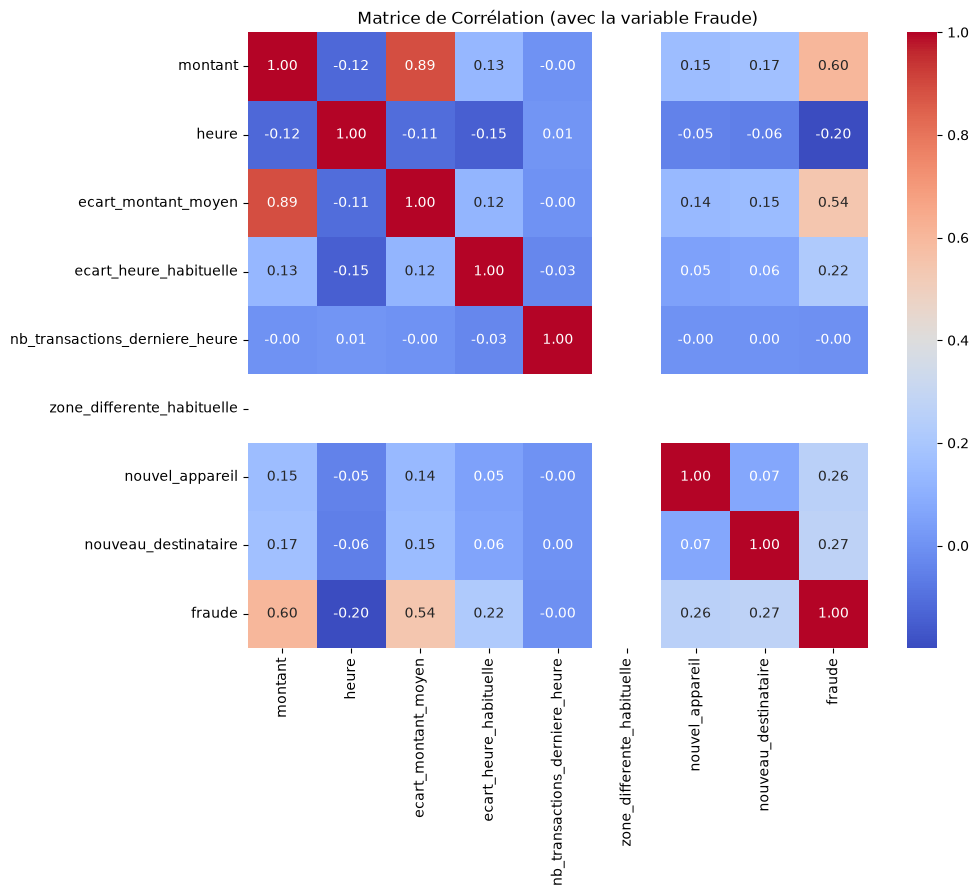

In [51]:
# Sélection des colonnes numériques ET booléennes
df_numeric = df.select_dtypes(include=['float64', 'int64', 'bool']).astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de Corrélation (avec la variable Fraude)")
plt.show()

In [52]:
#Suppression de la variable Zone_differente_habituelle 
df = df.drop(columns=['zone_differente_habituelle'])

In [53]:
df.head(10)

,id_transaction,montant,type,canal,heure,ecart_montant_moyen,ecart_heure_habituelle,nb_transactions_derniere_heure,nouvel_appareil,nouveau_destinataire,fraude
0,txn_00405079,9249.0,transfert,app,10,1.008213,4.246094,0.0,False,False,False
1,txn_00404809,11504.0,transfert,app,14,1.243810,4.000000,0.0,False,False,False
2,txn_00334072,950.0,transfert,app,18,0.091553,6.000000,0.0,False,False,False
3,txn_00020793,6938.0,paiement,app,14,0.959038,0.000000,0.0,False,False,False
4,txn_00333619,2718.0,paiement,app,17,0.379596,3.000000,0.0,False,True,False
5,txn_00274441,2659.0,dépôt,USSD,9,0.423961,5.600000,0.0,False,False,False
6,txn_00034682,5091.0,paiement,agent,12,0.897936,1.666667,0.0,False,False,False
7,txn_00066368,1308.0,paiement,app,12,0.234115,1.428571,0.0,False,False,False
8,txn_00447078,5401.0,transfert,app,20,1.069055,6.750000,0.0,False,True,False
9,txn_00334655,5435.0,transfert,agent,23,1.067594,9.000000,0.0,False,False,False


In [54]:
#Verification de la variable nb_transactions_derniere_heure 
df.groupby('nb_transactions_derniere_heure')['fraude'].mean()

nb_transactions_derniere_heure
0.0    0.025114
1.0    0.017216
2.0    0.000000
Name: fraude, dtype: float64

In [ ]:
#Suppression de la variable nb_trasanctions_derniere_heure
df = df.drop(columns=['nb_transactions_derniere_heure'])

In [56]:
df.head(10)

,id_transaction,montant,type,canal,heure,ecart_montant_moyen,ecart_heure_habituelle,nouvel_appareil,nouveau_destinataire,fraude
0,txn_00405079,9249.0,transfert,app,10,1.008213,4.246094,False,False,False
1,txn_00404809,11504.0,transfert,app,14,1.243810,4.000000,False,False,False
2,txn_00334072,950.0,transfert,app,18,0.091553,6.000000,False,False,False
3,txn_00020793,6938.0,paiement,app,14,0.959038,0.000000,False,False,False
4,txn_00333619,2718.0,paiement,app,17,0.379596,3.000000,False,True,False
5,txn_00274441,2659.0,dépôt,USSD,9,0.423961,5.600000,False,False,False
6,txn_00034682,5091.0,paiement,agent,12,0.897936,1.666667,False,False,False
7,txn_00066368,1308.0,paiement,app,12,0.234115,1.428571,False,False,False
8,txn_00447078,5401.0,transfert,app,20,1.069055,6.750000,False,True,False
9,txn_00334655,5435.0,transfert,agent,23,1.067594,9.000000,False,False,False


In [57]:
# 1. Effectifs bruts (nombre de lignes)
print("--- Effectifs bruts ---")
print(df["fraude"].value_counts())

--- Effectifs bruts ---
fraude
False    481235
True      12369
Name: count, dtype: int64


In [58]:
# 2. Proportions en pourcentage (%)
print("\n--- Proportions (%) ---")
print(df["fraude"].value_counts(normalize=True) * 100)


--- Proportions (%) ---
fraude
False    97.494145
True      2.505855
Name: proportion, dtype: float64


In [59]:
# Moyenne du montant selon le statut de fraude
df.groupby('fraude')['montant'].mean()

fraude
False      6030.774272
True     131452.498423
Name: montant, dtype: float64

In [60]:
# Taux de fraude par canal
taux_canal = df.groupby("canal")["fraude"].mean()

print(
    f"Canal le PLUS touché  : {taux_canal.idxmax()} ({taux_canal.max()*100:.2f}% de fraude)"
)
print(
    f"Canal le MOINS touché : {taux_canal.idxmin()} ({taux_canal.min()*100:.2f}% de fraude)"
)

Canal le PLUS touché  : agent (2.54% de fraude)
Canal le MOINS touché : Inconnu (2.29% de fraude)


In [61]:
# Analyse du nombre de fraudes par canal
analyse_canaux = (
    df.groupby("canal")["fraude"]
    .agg(
        nombre_de_fraudes="sum",
        total_transactions="count",
        taux_de_fraude_pct=lambda x: x.mean() * 100,
    )
    .sort_values(by="nombre_de_fraudes", ascending=False)
)

print(analyse_canaux)

         nombre_de_fraudes  total_transactions  taux_de_fraude_pct
canal                                                             
app                   6755              270251            2.499528
USSD                  3690              147360            2.504072
agent                 1876               73894            2.538772
Inconnu                 48                2099            2.286803


In [62]:
# Analyse complète par type de transaction
analyse_type = (
    df.groupby("type")["fraude"]
    .agg(
        nombre_de_fraudes="sum",
        total_transactions="count",
        taux_de_fraude_pct=lambda x: x.mean() * 100,
    )
    .sort_values(by="taux_de_fraude_pct", ascending=False)
)

print(analyse_type)

           nombre_de_fraudes  total_transactions  taux_de_fraude_pct
type                                                                
transfert               6267              247324            2.533923
paiement                3666              147803            2.480329
retrait                 1836               74061            2.479038
dépôt                    600               24416            2.457405


In [63]:
#Convertir le df en csv
df.to_csv("dataset_fraude_clean.csv", index=False)